In [121]:
# ==============================
# 1. IMPORT LIBRARIES
# ==============================

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder,
    LabelEncoder
)
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [122]:
# ==============================
# 2. LOAD DATASET
# ==============================

file_path = "fedmml_ed_triage_dataset.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully!
Shape: (87234, 28)


,encounter_id,patient_id,site_id,country,age,sex,arrival_timestamp,chief_complaint,clinical_notes,systolic_bp,diastolic_bp,heart_rate,respiratory_rate,temperature,spo2,pain_score,wbc,hemoglobin,platelet_count,sodium,potassium,creatinine,glucose,troponin,bnp,lactate,inr,esi_level
0,ENC1000001,PAT000001,1,Denmark,59,F,2021-01-30 12:33:00,Back pain,NaN,122.0,88.0,80.0,16.0,38.2,97.2,6.0,7.37,15.5,244.0,142.1,3.77,0.74,75.0,0.0,65.0,1.13,1.01,3
1,ENC1000002,PAT000002,1,Denmark,67,M,2022-02-26 01:46:00,Medication question,67yo M requesting Medication question. Patient...,138.0,68.0,82.0,18.0,36.7,98.4,2.0,7.57,12.6,242.0,138.4,4.09,1.15,84.0,0.0,85.0,1.24,0.68,5
2,ENC1000003,PAT000003,1,Denmark,58,F,2021-10-20 08:55:00,Cold symptoms,"58yo F here for Cold symptoms. Patient stable,...",114.0,76.0,85.0,16.0,37.6,97.8,1.0,11.03,13.9,296.0,139.0,3.82,1.11,111.0,0.0,56.0,0.94,1.12,4
3,ENC1000004,PAT000004,1,Denmark,23,F,2021-01-11 20:11:00,Laceration requiring sutures,23yo F presents with Laceration requiring sutu...,137.0,81.0,79.0,20.0,38.0,91.6,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3
4,ENC1000005,PAT000005,1,Denmark,64,F,2023-11-05 13:44:00,Chest pain,64yo F c/o Chest pain. Patient in moderate dis...,141.0,71.0,99.0,21.0,37.8,98.8,8.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2


In [123]:
# ==============================
# 3. BASIC INFORMATION
# ==============================

print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nDataset information:")
df.info()

Number of rows: 87234
Number of columns: 28

Column names:
['encounter_id', 'patient_id', 'site_id', 'country', 'age', 'sex', 'arrival_timestamp', 'chief_complaint', 'clinical_notes', 'systolic_bp', 'diastolic_bp', 'heart_rate', 'respiratory_rate', 'temperature', 'spo2', 'pain_score', 'wbc', 'hemoglobin', 'platelet_count', 'sodium', 'potassium', 'creatinine', 'glucose', 'troponin', 'bnp', 'lactate', 'inr', 'esi_level']

Data types:
encounter_id             str
patient_id               str
site_id                int64
country                  str
age                    int64
sex                      str
arrival_timestamp        str
chief_complaint          str
clinical_notes           str
systolic_bp          float64
diastolic_bp         float64
heart_rate           float64
respiratory_rate     float64
temperature          float64
spo2                 float64
pain_score           float64
wbc                  float64
hemoglobin           float64
platelet_count       float64
sodium       

In [124]:
# ==============================
# 4. STATISTICAL SUMMARY
# ==============================

df.describe()

,site_id,age,systolic_bp,diastolic_bp,heart_rate,respiratory_rate,temperature,spo2,pain_score,wbc,hemoglobin,platelet_count,sodium,potassium,creatinine,glucose,troponin,bnp,lactate,inr,esi_level
count,87234.000000,87234.000000,81742.000000,81742.000000,81742.000000,81742.000000,81742.000000,81742.000000,81742.000000,60631.000000,60631.000000,60631.000000,60631.000000,60631.000000,60631.000000,60631.000000,60631.000000,60631.000000,60631.000000,60631.000000,87234.000000
mean,3.274010,51.923654,129.690551,82.136919,87.158278,18.132992,37.472881,95.971112,4.458809,8.291628,13.680606,243.494714,139.772638,4.039366,0.984407,109.312926,0.018781,116.576520,1.378746,1.046464,3.165394
std,1.722482,18.102583,18.016627,11.280634,16.616061,3.852378,0.737290,2.813958,2.158720,2.840701,1.442618,44.603364,2.649617,0.383016,0.313102,29.155491,0.079983,91.878174,0.527705,0.224893,0.836431
min,1.000000,18.000000,43.000000,3.000000,31.000000,2.000000,34.000000,75.400000,0.000000,-0.960000,4.400000,-4.000000,119.100000,2.240000,-0.200000,4.000000,-0.135000,-156.000000,-0.760000,0.080000,1.000000
25%,2.000000,39.000000,118.000000,75.000000,76.000000,16.000000,37.000000,94.500000,3.000000,6.410000,12.800000,215.000000,138.300000,3.800000,0.790000,92.000000,0.000000,65.000000,1.050000,0.910000,3.000000
50%,3.000000,52.000000,128.000000,82.000000,86.000000,18.000000,37.300000,96.600000,5.000000,7.960000,13.800000,245.000000,139.900000,4.020000,0.940000,104.000000,0.000000,89.000000,1.280000,1.020000,3.000000
75%,5.000000,64.000000,140.000000,89.000000,97.000000,20.000000,37.900000,98.000000,6.000000,9.730000,14.700000,273.000000,141.400000,4.250000,1.120000,118.000000,0.000000,122.000000,1.570000,1.150000,4.000000
max,6.000000,100.000000,229.000000,141.000000,183.000000,44.000000,41.300000,105.100000,10.000000,25.260000,18.900000,430.000000,157.300000,6.800000,4.460000,406.000000,1.632000,921.000000,6.300000,3.580000,5.000000


In [125]:
# ==============================
# 5. DUPLICATE CHECK
# ==============================

duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

if duplicate_count > 0:
    df = df.drop_duplicates()
    print("Duplicates removed.")
else:
    print("No duplicate rows found.")

Number of duplicate rows: 0
No duplicate rows found.


In [126]:
# ==============================
# 6. MISSING VALUE ANALYSIS
# ==============================

missing = pd.DataFrame({
    "Missing_Count": df.isnull().sum(),
    "Missing_Percentage": df.isnull().mean() * 100
})

missing = missing.sort_values(
    by="Missing_Percentage",
    ascending=False
)

print(missing)

                   Missing_Count  Missing_Percentage
platelet_count             26603           30.496137
inr                        26603           30.496137
lactate                    26603           30.496137
bnp                        26603           30.496137
troponin                   26603           30.496137
glucose                    26603           30.496137
creatinine                 26603           30.496137
hemoglobin                 26603           30.496137
sodium                     26603           30.496137
wbc                        26603           30.496137
potassium                  26603           30.496137
temperature                 5492            6.295710
pain_score                  5492            6.295710
spo2                        5492            6.295710
respiratory_rate            5492            6.295710
heart_rate                  5492            6.295710
diastolic_bp                5492            6.295710
systolic_bp                 5492            6.

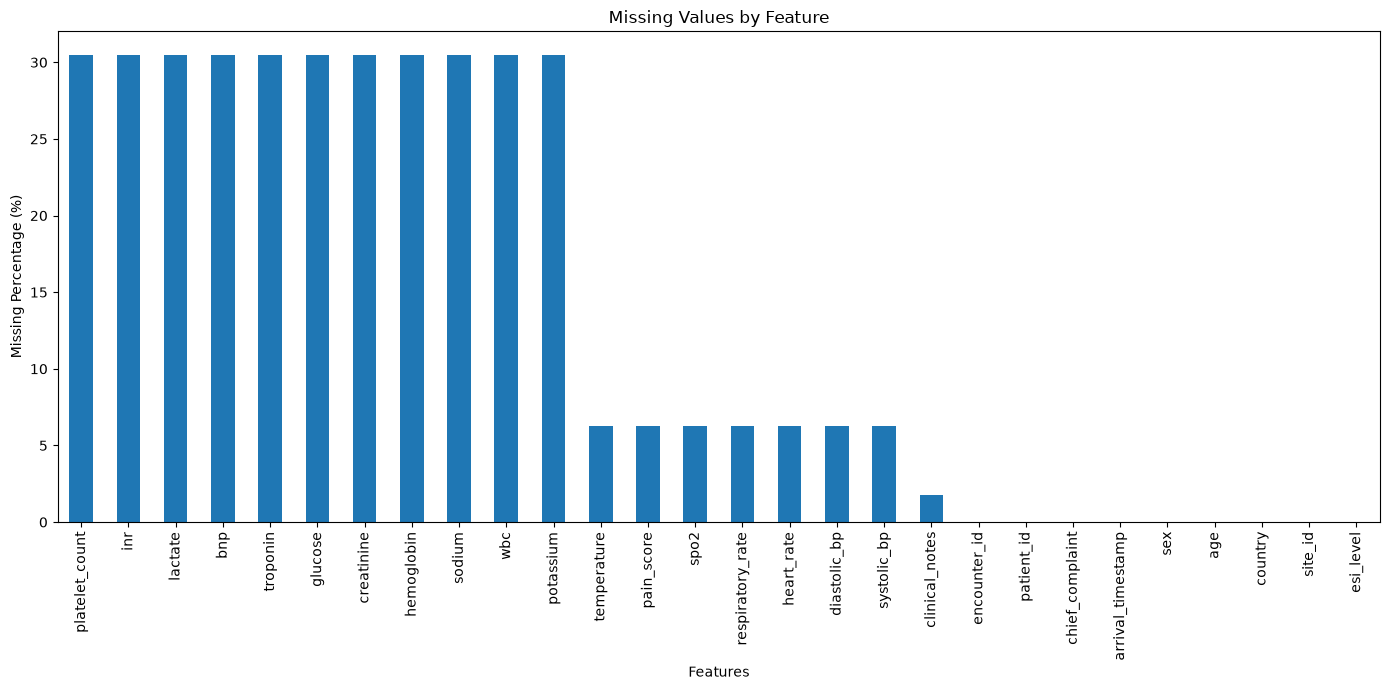

In [127]:
# ==============================
# MISSING VALUE PLOT
# ==============================

plt.figure(figsize=(14, 7))

missing["Missing_Percentage"].plot(
    kind="bar"
)

plt.title("Missing Values by Feature")
plt.xlabel("Features")
plt.ylabel("Missing Percentage (%)")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [128]:
# ==============================
# 7. TARGET DISTRIBUTION
# ==============================

print(df["esi_level"].value_counts().sort_index())

print("\nPercentage distribution:")
print(
    df["esi_level"]
    .value_counts(normalize=True)
    .sort_index() * 100
)

esi_level
1      924
2    16789
3    41389
4    23199
5     4933
Name: count, dtype: int64

Percentage distribution:
esi_level
1     1.059220
2    19.245936
3    47.445950
4    26.593989
5     5.654905
Name: proportion, dtype: float64


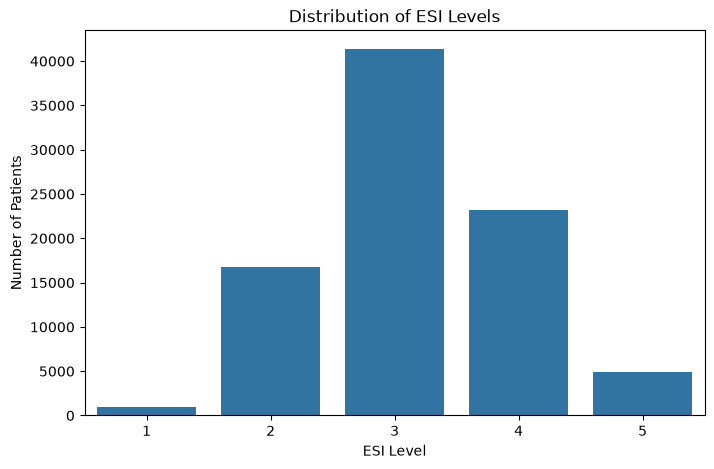

In [129]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="esi_level"
)

plt.title("Distribution of ESI Levels")
plt.xlabel("ESI Level")
plt.ylabel("Number of Patients")

plt.show()

In [130]:
# ==============================
# 8. NUMERICAL FEATURES
# ==============================

numeric_columns = df.select_dtypes(
    include=["int64", "float64"]
).columns

print("Numerical columns:")
print(numeric_columns.tolist())

Numerical columns:
['site_id', 'age', 'systolic_bp', 'diastolic_bp', 'heart_rate', 'respiratory_rate', 'temperature', 'spo2', 'pain_score', 'wbc', 'hemoglobin', 'platelet_count', 'sodium', 'potassium', 'creatinine', 'glucose', 'troponin', 'bnp', 'lactate', 'inr', 'esi_level']


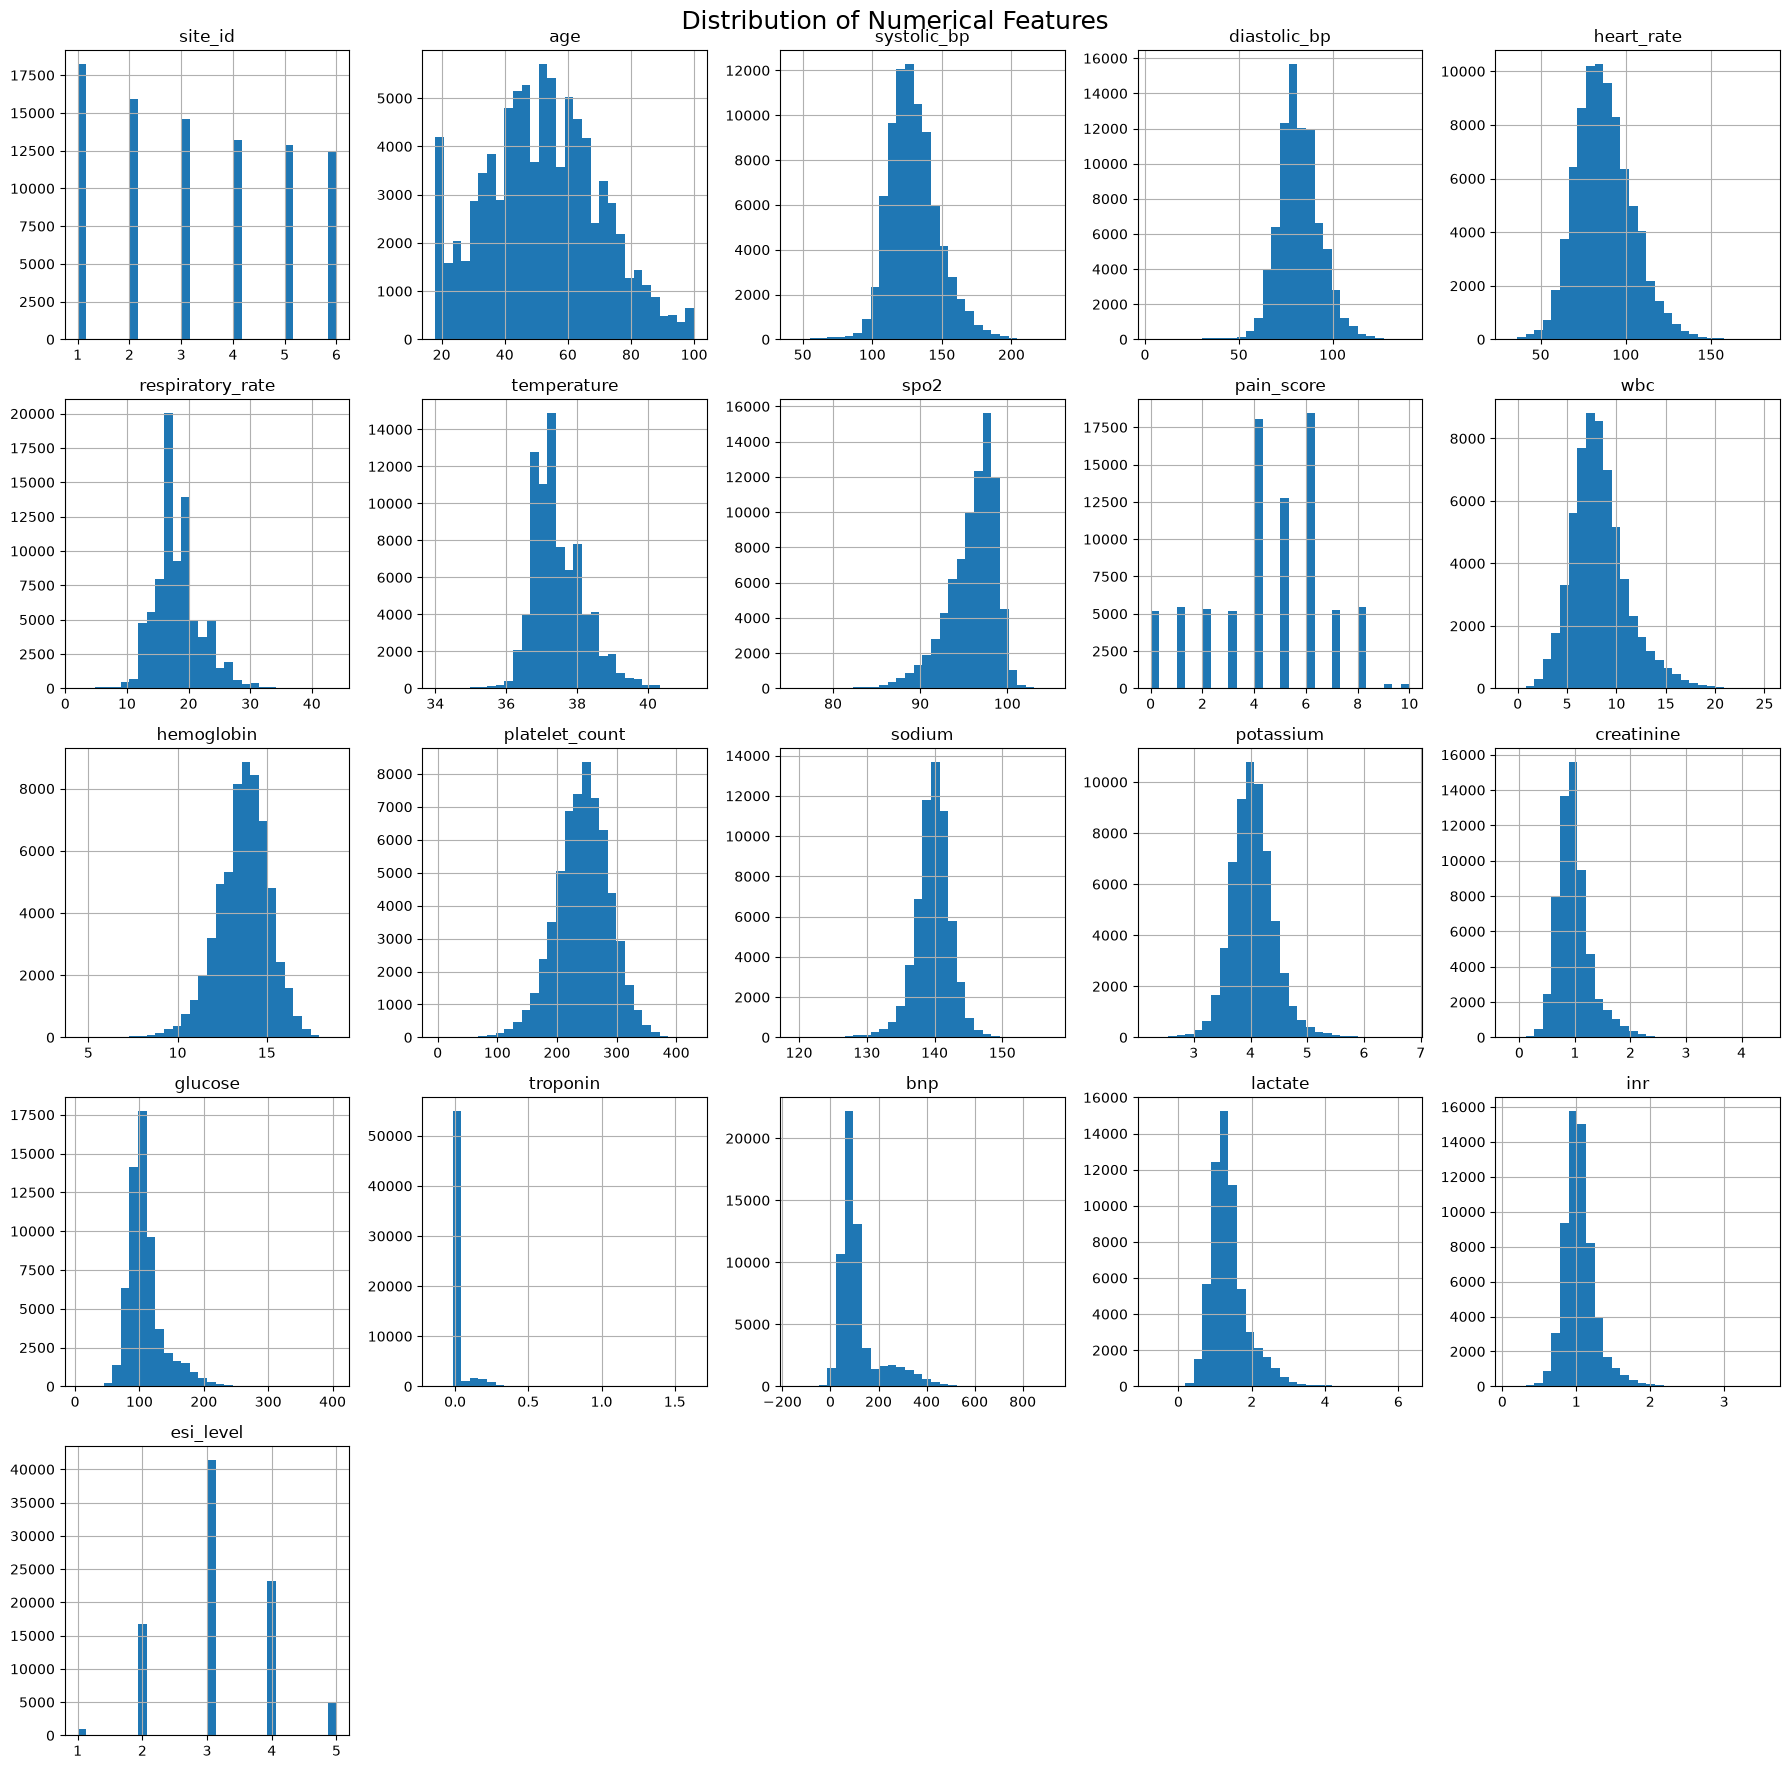

In [131]:
# ==============================
# NUMERICAL FEATURE DISTRIBUTION
# ==============================

df[numeric_columns].hist(
    figsize=(18, 18),
    bins=30
)

plt.suptitle(
    "Distribution of Numerical Features",
    fontsize=18
)

plt.tight_layout()
plt.show()

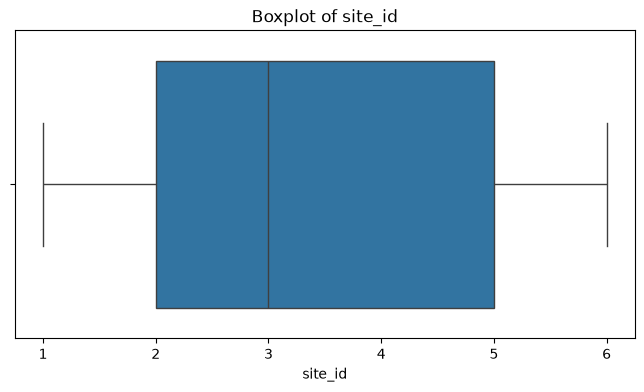

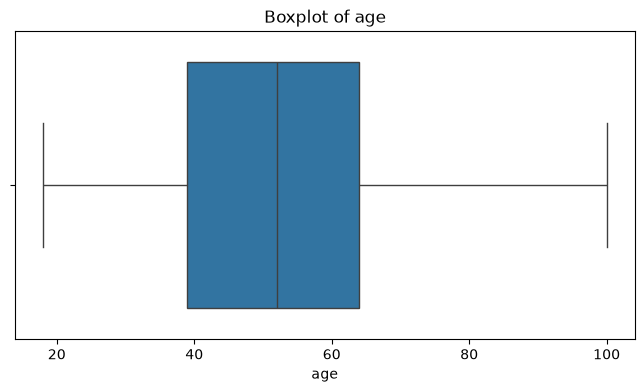

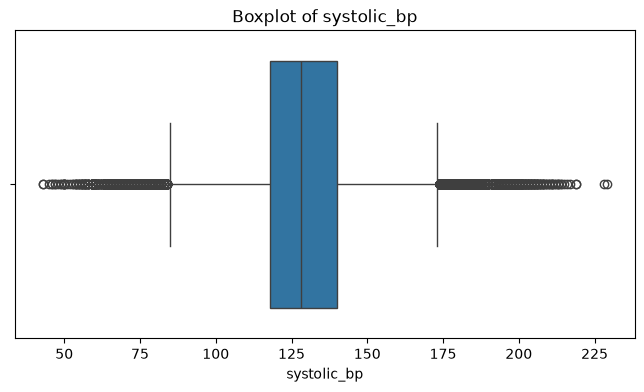

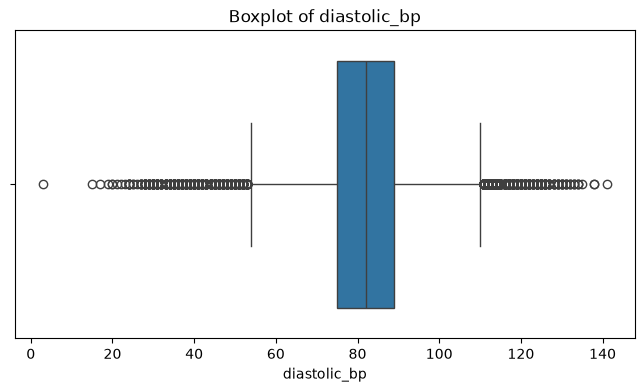

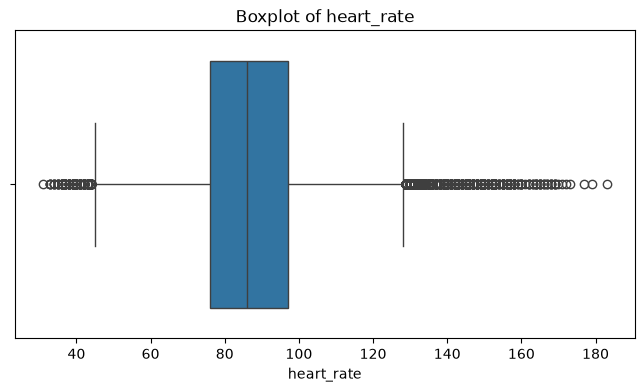

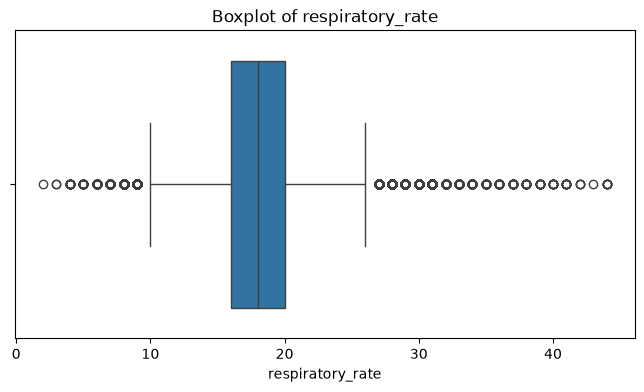

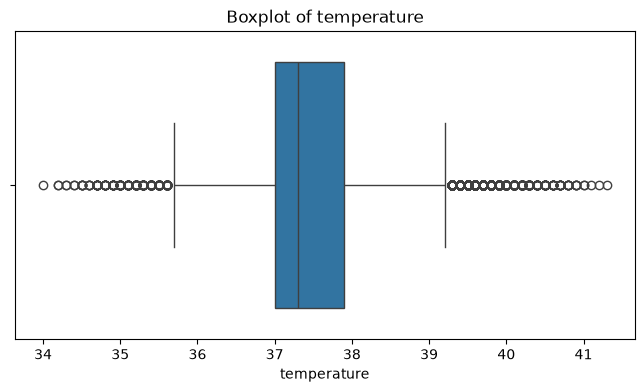

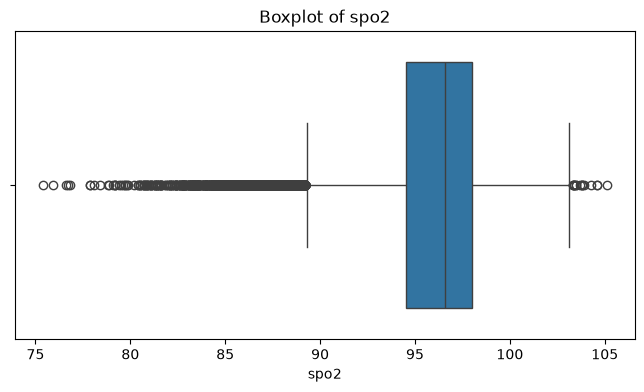

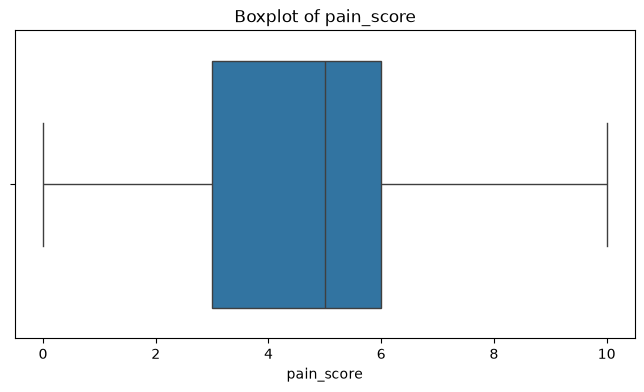

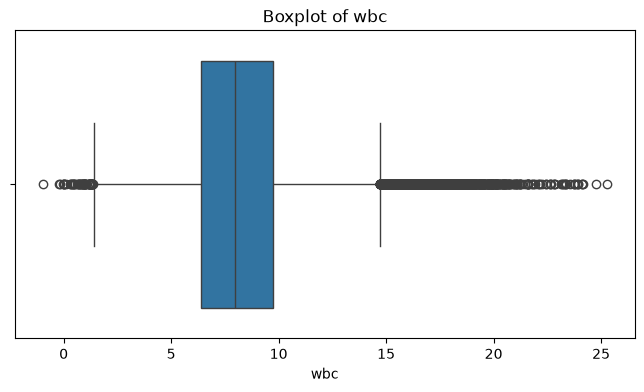

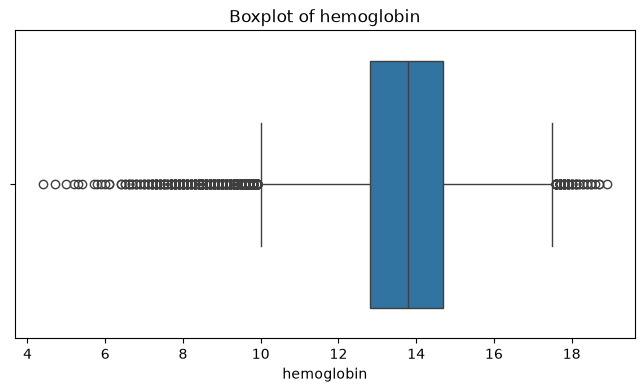

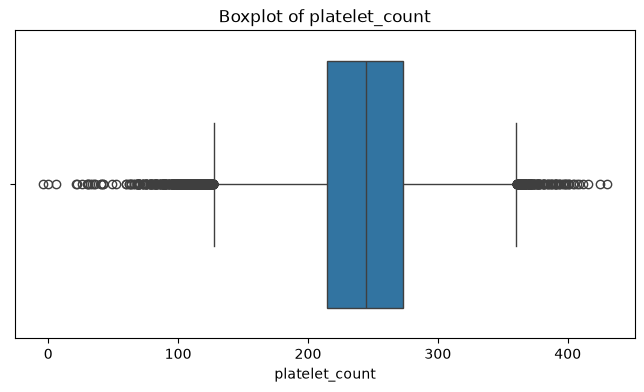

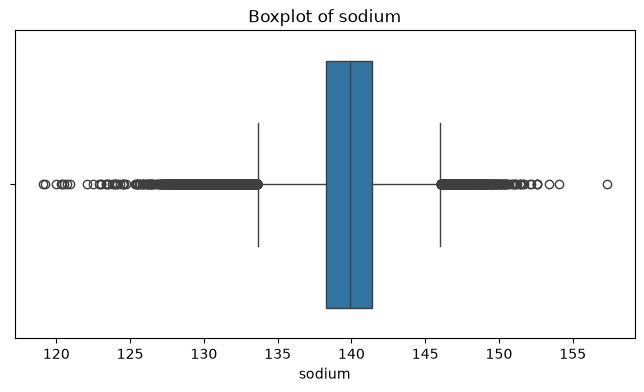

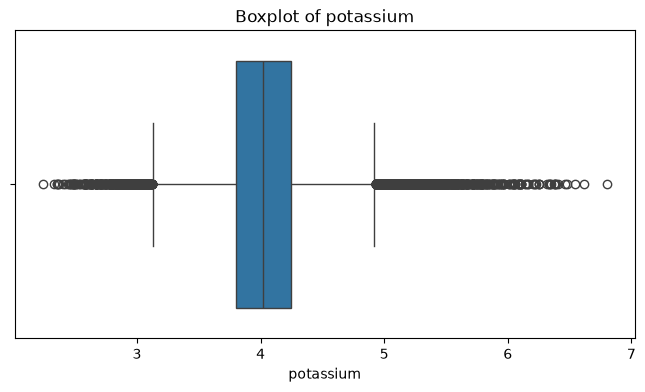

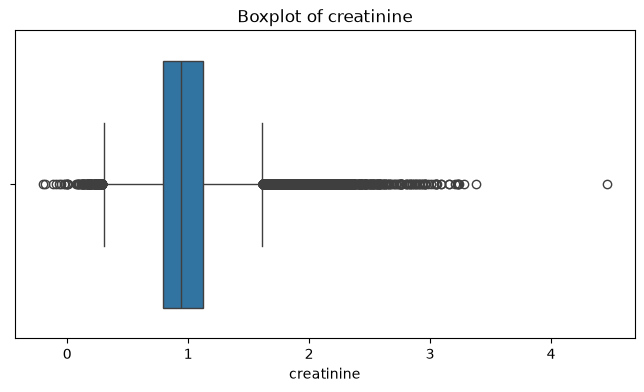

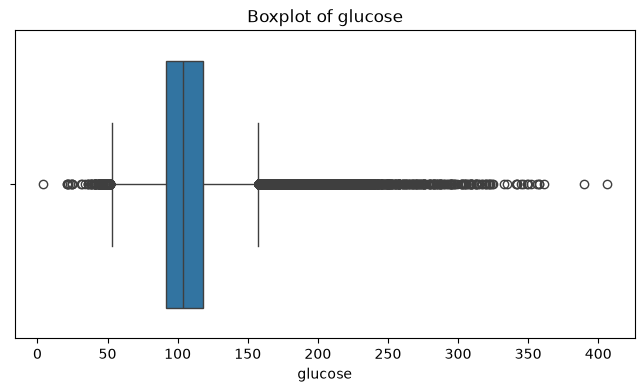

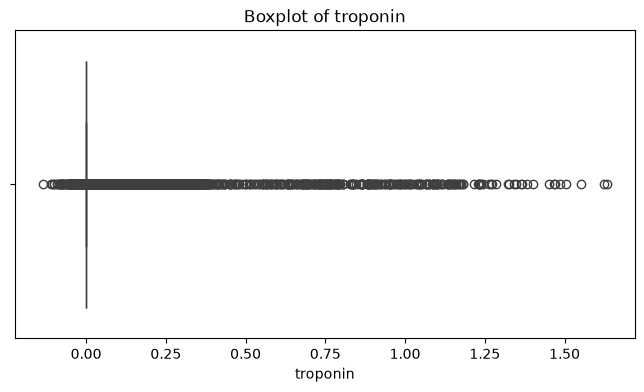

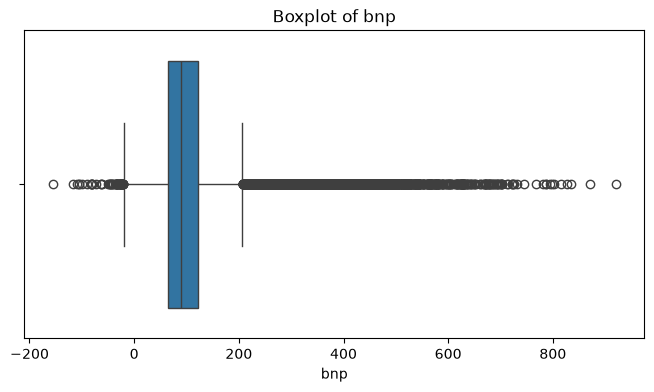

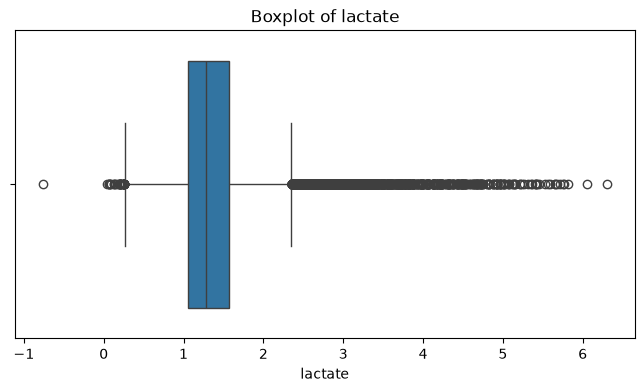

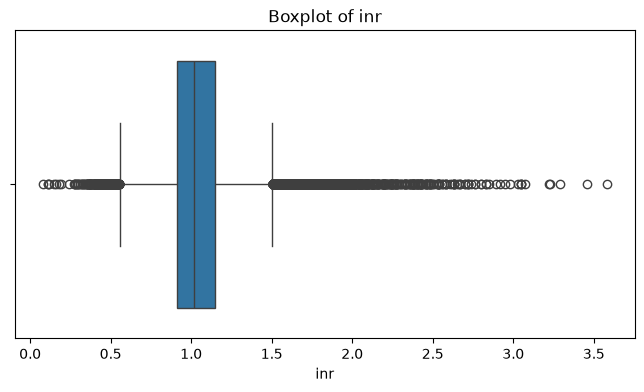

In [132]:
# ==============================
# OUTLIER VISUALIZATION
# ==============================

for column in numeric_columns:

    if column == "esi_level":
        continue

    plt.figure(figsize=(8, 4))

    sns.boxplot(
        x=df[column]
    )

    plt.title(f"Boxplot of {column}")
    plt.xlabel(column)

    plt.show()

In [133]:
# ==============================
# IQR OUTLIER DETECTION
# ==============================

def detect_outliers_iqr(data, column):

    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = data[
        (data[column] < lower_bound) |
        (data[column] > upper_bound)
    ]

    return len(outliers), lower_bound, upper_bound


for column in numeric_columns:

    if column == "esi_level":
        continue

    count, lower, upper = detect_outliers_iqr(
        df,
        column
    )

    print(
        f"{column:20s} "
        f"Outliers: {count:6d} "
        f"Range: [{lower:.2f}, {upper:.2f}]"
    )

site_id              Outliers:      0 Range: [-2.50, 9.50]
age                  Outliers:      0 Range: [1.50, 101.50]
systolic_bp          Outliers:   2035 Range: [85.00, 173.00]
diastolic_bp         Outliers:   1532 Range: [54.00, 110.00]
heart_rate           Outliers:   1466 Range: [44.50, 128.50]
respiratory_rate     Outliers:   3008 Range: [10.00, 26.00]
temperature          Outliers:   2192 Range: [35.65, 39.25]
spo2                 Outliers:   2320 Range: [89.25, 103.25]
pain_score           Outliers:      0 Range: [-1.50, 10.50]
wbc                  Outliers:   1955 Range: [1.43, 14.71]
hemoglobin           Outliers:    862 Range: [9.95, 17.55]
platelet_count       Outliers:    736 Range: [128.00, 360.00]
sodium               Outliers:   1895 Range: [133.65, 146.05]
potassium            Outliers:   1745 Range: [3.12, 4.93]
creatinine           Outliers:   3012 Range: [0.29, 1.62]
glucose              Outliers:   4630 Range: [53.00, 157.00]
troponin             Outliers:   6127 

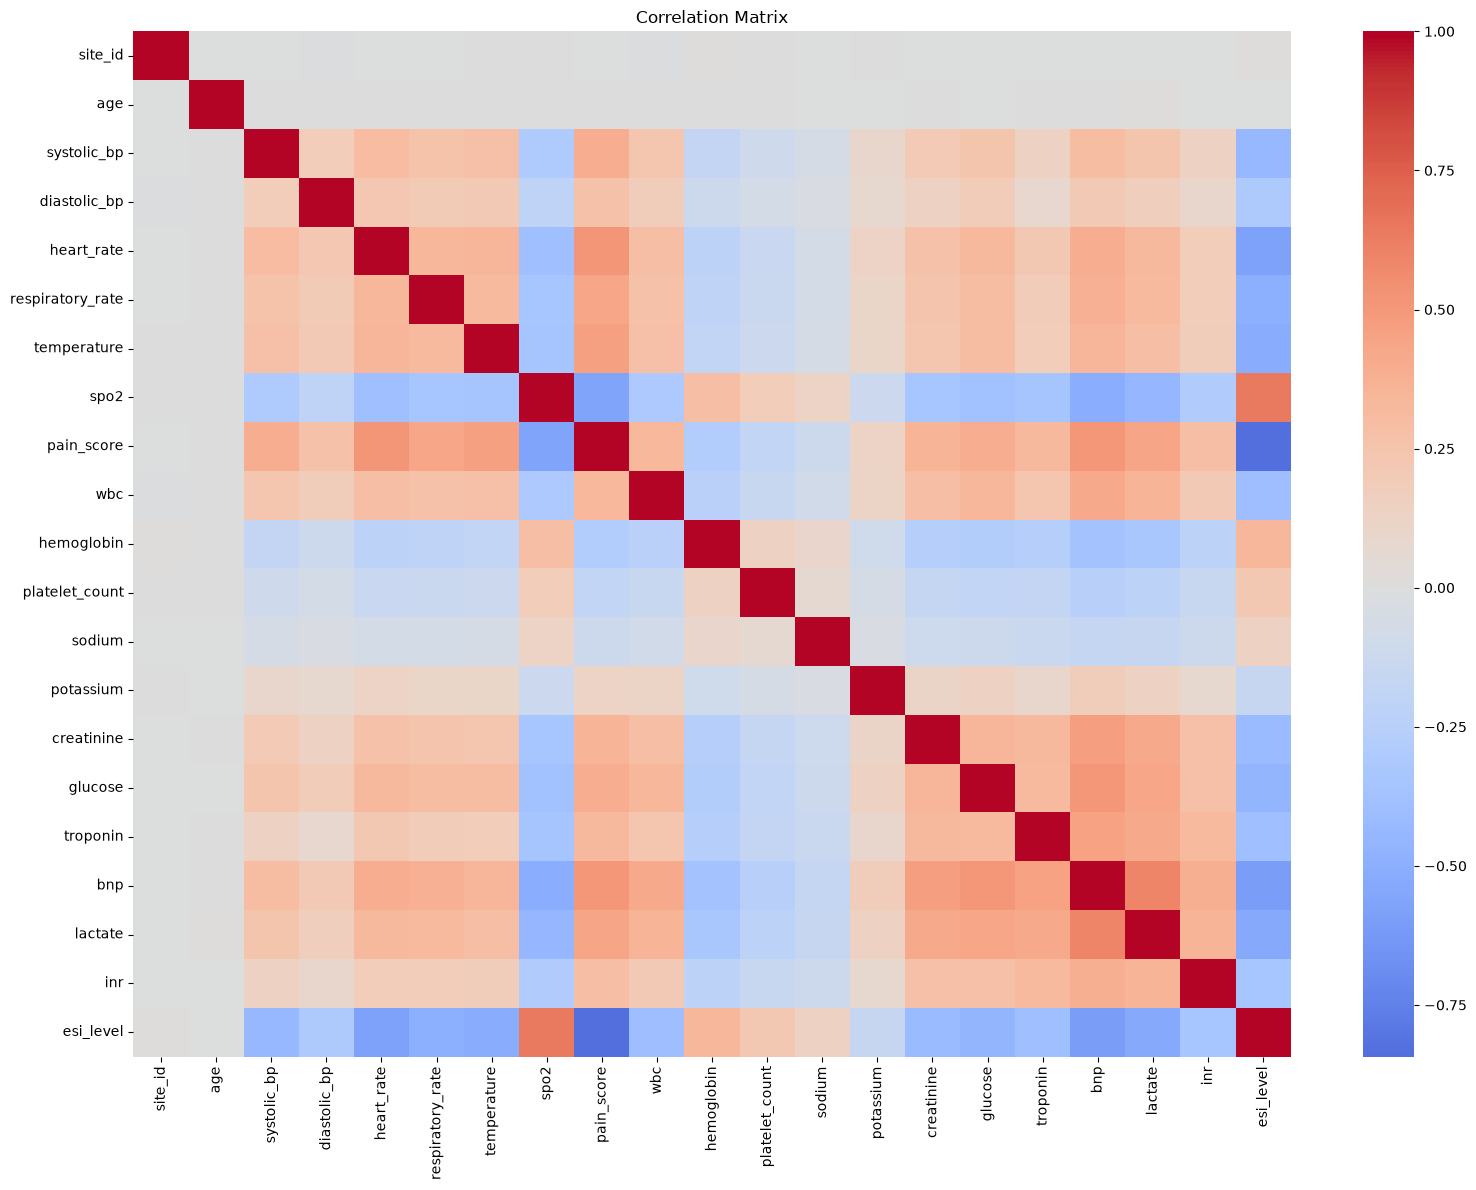

In [134]:
# ==============================
# CORRELATION MATRIX
# ==============================

plt.figure(figsize=(16, 12))

correlation = df[numeric_columns].corr()

sns.heatmap(
    correlation,
    cmap="coolwarm",
    center=0,
    annot=False
)

plt.title("Correlation Matrix")

plt.tight_layout()
plt.show()

In [135]:
# ==============================
# CORRELATION WITH TARGET
# ==============================

esi_correlation = (
    correlation["esi_level"]
    .sort_values(ascending=False)
)

print(esi_correlation)

esi_level           1.000000
spo2                0.645653
hemoglobin          0.341771
platelet_count      0.220369
sodium              0.143617
site_id             0.006847
age                -0.001983
potassium          -0.158443
diastolic_bp       -0.305787
inr                -0.341437
troponin           -0.391296
wbc                -0.396788
creatinine         -0.419410
systolic_bp        -0.436893
glucose            -0.466367
respiratory_rate   -0.491017
temperature        -0.518626
lactate            -0.527154
heart_rate         -0.581252
bnp                -0.604047
pain_score         -0.842826
Name: esi_level, dtype: float64


In [136]:
# ==============================
# CATEGORICAL FEATURES
# ==============================

categorical_columns = df.select_dtypes(
    include=["object"]
).columns

print(categorical_columns.tolist())

['encounter_id', 'patient_id', 'country', 'sex', 'arrival_timestamp', 'chief_complaint', 'clinical_notes']


In [137]:
for column in categorical_columns:

    print("\n" + "=" * 60)
    print(column)

    print(
        df[column]
        .value_counts(dropna=False)
        .head(20)
    )


encounter_id
encounter_id
ENC1000001    1
ENC1000002    1
ENC1000003    1
ENC1000004    1
ENC1000005    1
ENC1000006    1
ENC1000007    1
ENC1000008    1
ENC1000009    1
ENC1000010    1
ENC1000011    1
ENC1000012    1
ENC1000013    1
ENC1000014    1
ENC1000015    1
ENC1000016    1
ENC1000017    1
ENC1000018    1
ENC1000019    1
ENC1000020    1
Name: count, dtype: int64

patient_id
patient_id
PAT000001    7861
PAT000002    7185
PAT000003    6561
PAT000004    5957
PAT000005    5460
PAT000006    4992
PAT000007    4513
PAT000008    4096
PAT000009    3724
PAT000010    3382
PAT000011    3089
PAT000012    2778
PAT000013    2546
PAT000014    2317
PAT000015    2101
PAT000016    1936
PAT000017    1726
PAT000018    1573
PAT000019    1440
PAT000020    1322
Name: count, dtype: int64

country
country
Denmark    34126
Turkey     27801
Latvia     25307
Name: count, dtype: int64

sex
sex
F    44643
M    42591
Name: count, dtype: int64

arrival_timestamp
arrival_timestamp
2021-03-18 02:55:00    3
2022-

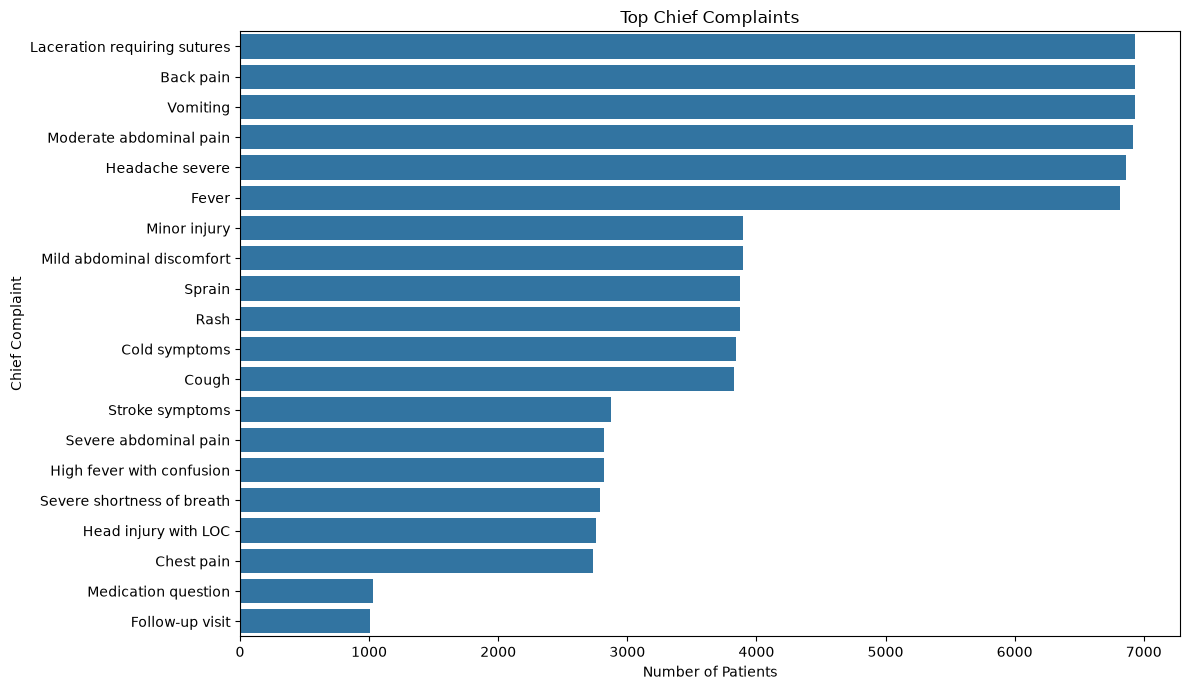

In [138]:
# ==============================
# CHIEF COMPLAINT ANALYSIS
# ==============================

complaint_counts = (
    df["chief_complaint"]
    .value_counts()
    .head(20)
)

plt.figure(figsize=(12, 7))

sns.barplot(
    x=complaint_counts.values,
    y=complaint_counts.index
)

plt.title("Top Chief Complaints")
plt.xlabel("Number of Patients")
plt.ylabel("Chief Complaint")

plt.tight_layout()
plt.show()

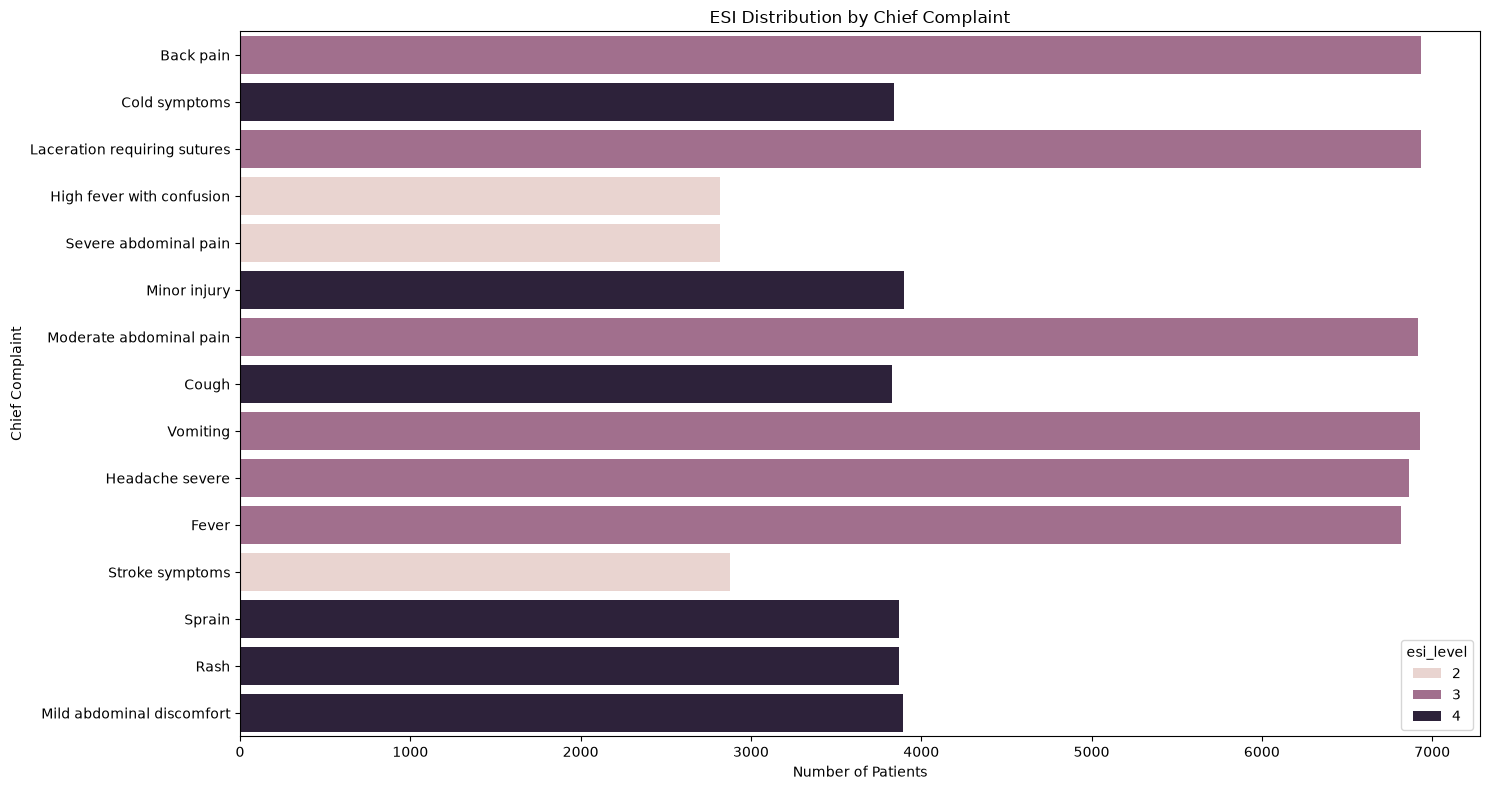

In [139]:
# ==============================
# ESI BY CHIEF COMPLAINT
# ==============================

plt.figure(figsize=(15, 8))

top_complaints = (
    df["chief_complaint"]
    .value_counts()
    .head(15)
    .index
)

temp = df[
    df["chief_complaint"].isin(top_complaints)
]

sns.countplot(
    data=temp,
    y="chief_complaint",
    hue="esi_level"
)

plt.title("ESI Distribution by Chief Complaint")
plt.xlabel("Number of Patients")
plt.ylabel("Chief Complaint")

plt.tight_layout()
plt.show()

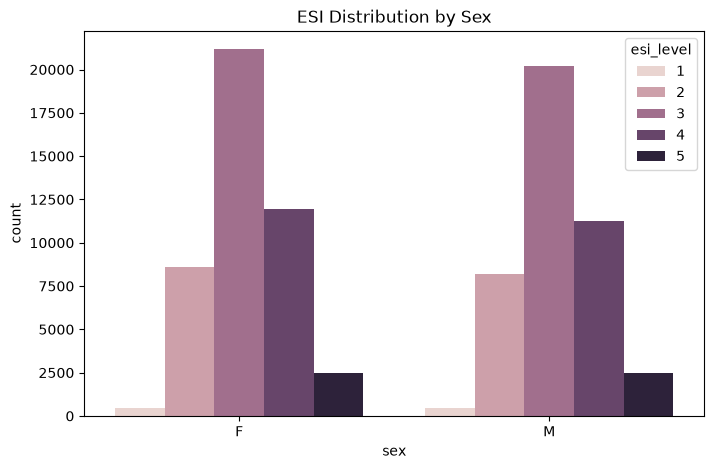

In [140]:
# ==============================
# ESI VS SEX
# ==============================

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="sex",
    hue="esi_level"
)

plt.title("ESI Distribution by Sex")

plt.show()

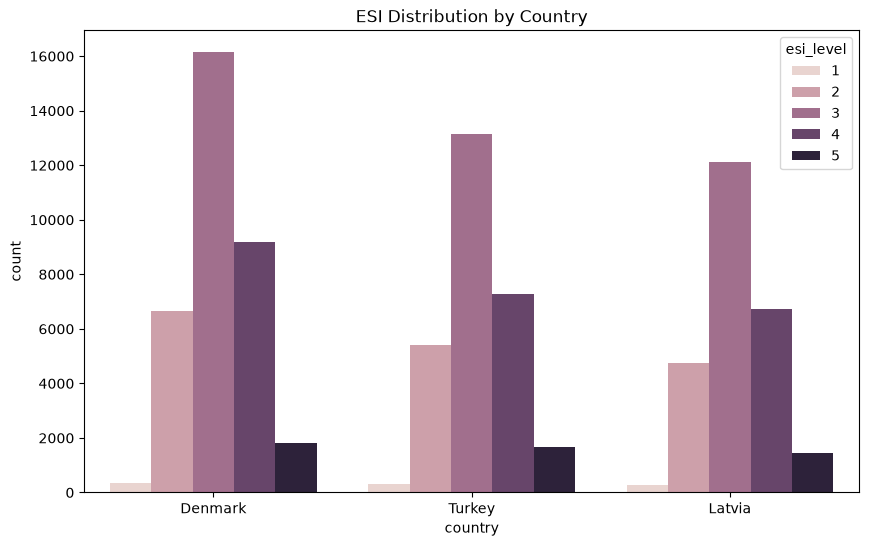

In [141]:
# ==============================
# ESI VS COUNTRY
# ==============================

plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    x="country",
    hue="esi_level"
)

plt.title("ESI Distribution by Country")

plt.show()

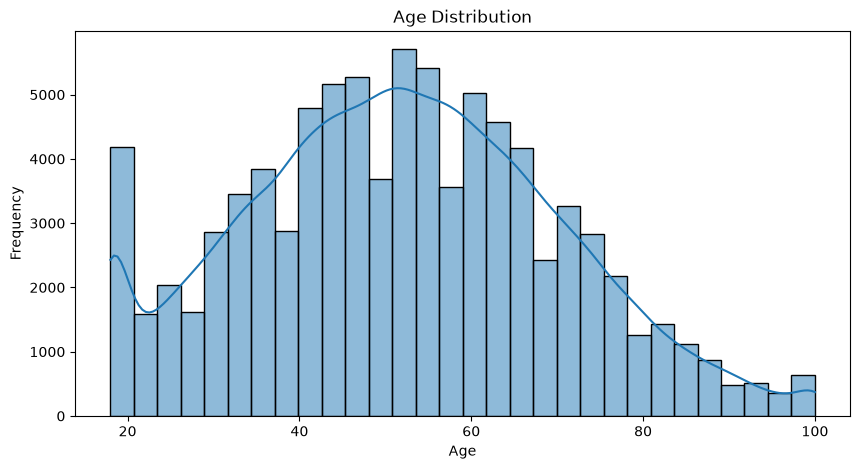

In [142]:
# ==============================
# AGE DISTRIBUTION
# ==============================

plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x="age",
    bins=30,
    kde=True
)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

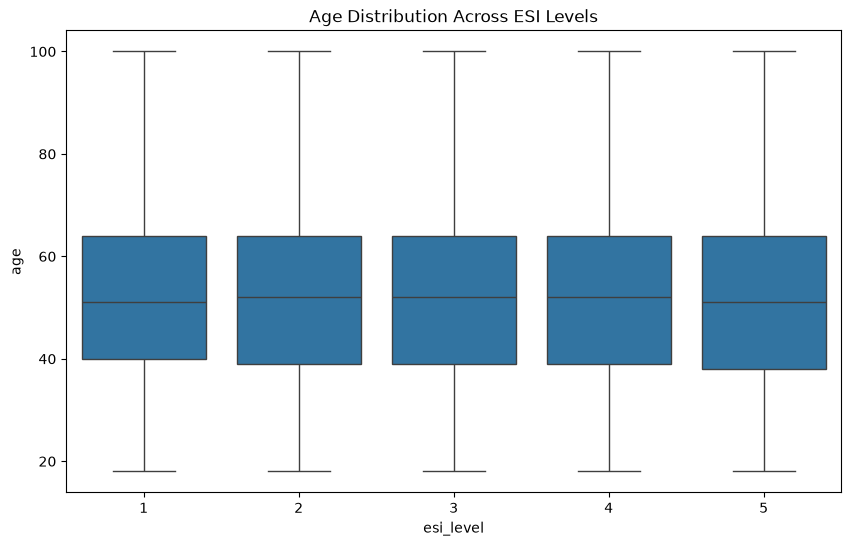

In [143]:
# ==============================
# AGE VS ESI
# ==============================

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="esi_level",
    y="age"
)

plt.title("Age Distribution Across ESI Levels")

plt.show()

In [144]:
# ==============================
# 21. DATETIME PROCESSING
# ==============================

df["arrival_timestamp"] = pd.to_datetime(
    df["arrival_timestamp"],
    errors="coerce"
)

df["arrival_year"] = df["arrival_timestamp"].dt.year
df["arrival_month"] = df["arrival_timestamp"].dt.month
df["arrival_day"] = df["arrival_timestamp"].dt.day
df["arrival_hour"] = df["arrival_timestamp"].dt.hour
df["arrival_dayofweek"] = df["arrival_timestamp"].dt.dayofweek

df["is_weekend"] = (
    df["arrival_dayofweek"] >= 5
).astype(int)

print(
    df[
        [
            "arrival_timestamp",
            "arrival_year",
            "arrival_month",
            "arrival_hour",
            "arrival_dayofweek",
            "is_weekend"
        ]
    ].head()
)

    arrival_timestamp  arrival_year  arrival_month  arrival_hour  \
0 2021-01-30 12:33:00          2021              1            12   
1 2022-02-26 01:46:00          2022              2             1   
2 2021-10-20 08:55:00          2021             10             8   
3 2021-01-11 20:11:00          2021              1            20   
4 2023-11-05 13:44:00          2023             11            13   

   arrival_dayofweek  is_weekend  
0                  5           1  
1                  5           1  
2                  2           0  
3                  0           0  
4                  6           1  


In [145]:
# ==============================
# 22. REMOVE IDENTIFIERS
# ==============================

identifier_columns = [
    "encounter_id",
    "patient_id"
]

df_model = df.drop(
    columns=identifier_columns
)

print(df_model.shape)

(87234, 32)


In [146]:
# ==============================
# 23. TEXT PREPROCESSING
# ==============================

df["clinical_notes"] = df["clinical_notes"].fillna("")

df["text"] = (
    df["chief_complaint"].fillna("") +
    " " +
    df["clinical_notes"].fillna("")
)

df["text"] = (
    df["text"]
    .str.lower()
    .str.replace(r"[^a-zA-Z0-9\s]", " ", regex=True)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

df["text"].head()

0                                            back pain
1    medication question 67yo m requesting medicati...
2    cold symptoms 58yo f here for cold symptoms pa...
3    laceration requiring sutures 23yo f presents w...
4    chest pain 64yo f c o chest pain patient in mo...
Name: text, dtype: str

In [147]:
# ==============================
# 24. TF-IDF
# ==============================

tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

X_text = tfidf.fit_transform(
    df["text"]
)

print("TF-IDF shape:", X_text.shape)

TF-IDF shape: (87234, 2728)


In [148]:
# ==============================
# 25. TARGET
# ==============================

y = df["esi_level"].astype(int)

print(y.value_counts().sort_index())

esi_level
1      924
2    16789
3    41389
4    23199
5     4933
Name: count, dtype: int64


In [149]:
label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

print("Original classes:")
print(label_encoder.classes_)

print("\nEncoded classes:")
print(np.unique(y_encoded))

Original classes:
[1 2 3 4 5]

Encoded classes:
[0 1 2 3 4]


In [150]:
numerical_features = [
    "age",
    "systolic_bp",
    "diastolic_bp",
    "heart_rate",
    "respiratory_rate",
    "temperature",
    "spo2",
    "pain_score",
    "wbc",
    "hemoglobin",
    "platelet_count",
    "sodium",
    "potassium",
    "creatinine",
    "glucose",
    "troponin",
    "bnp",
    "lactate",
    "inr",
    "arrival_year",
    "arrival_month",
    "arrival_hour",
    "arrival_dayofweek",
    "is_weekend"
]

In [151]:
categorical_features = [
    "site_id",
    "country",
    "sex",
    "chief_complaint"
]

In [152]:
# ==============================
# 27. PREPROCESSING PIPELINE
# ==============================

numerical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numerical_pipeline,
            numerical_features
        ),
        (
            "cat",
            categorical_pipeline,
            categorical_features
        )
    ]
)

In [153]:
# ==============================
# 28. PATIENT-LEVEL SPLIT
# ==============================

from sklearn.model_selection import GroupShuffleSplit

X = df[
    numerical_features +
    categorical_features
]

y = df["esi_level"]

groups = df["patient_id"]

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx, test_idx = next(
    gss.split(
        X,
        y,
        groups=groups
    )
)

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]

y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

print("Training:", X_train.shape)
print("Testing:", X_test.shape)

Training: (63827, 28)
Testing: (23407, 28)


In [154]:
gss_val = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx2, val_idx = next(
    gss_val.split(
        X_train,
        y_train,
        groups=df.iloc[train_idx]["patient_id"]
    )
)

X_train_final = X_train.iloc[train_idx2]
X_val = X_train.iloc[val_idx]

y_train_final = y_train.iloc[train_idx2]
y_val = y_train.iloc[val_idx]

print("Train:", X_train_final.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (46970, 28)
Validation: (16857, 28)
Test: (23407, 28)


In [155]:
# ==============================
# 29. FIT PREPROCESSOR
# ==============================

X_train_processed = preprocessor.fit_transform(
    X_train_final
)

X_val_processed = preprocessor.transform(
    X_val
)

X_test_processed = preprocessor.transform(
    X_test
)

print(
    "Processed training shape:",
    X_train_processed.shape
)

print(
    "Processed validation shape:",
    X_val_processed.shape
)

print(
    "Processed testing shape:",
    X_test_processed.shape
)

Processed training shape: (46970, 63)
Processed validation shape: (16857, 63)
Processed testing shape: (23407, 63)


In [156]:
# ==============================
# 30. CLASS WEIGHTS
# ==============================

from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(y_train_final)

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train_final
)

class_weights = dict(
    zip(classes, weights)
)

print(class_weights)

{np.int64(1): np.float64(17.724528301886792), np.int64(2): np.float64(1.0537296690970275), np.int64(3): np.float64(0.4219936211311262), np.int64(4): np.float64(0.7485855446649136), np.int64(5): np.float64(3.460036832412523)}


In [157]:
# ==============================
# 31. FINAL CHECK
# ==============================

print("NaN values in original data:")
print(df.isnull().sum().sum())

print("\nTraining matrix shape:")
print(X_train_processed.shape)

print("\nValidation matrix shape:")
print(X_val_processed.shape)

print("\nTesting matrix shape:")
print(X_test_processed.shape)

NaN values in original data:
331077

Training matrix shape:
(46970, 63)

Validation matrix shape:
(16857, 63)

Testing matrix shape:
(23407, 63)


In [158]:
# ==============================
# 32. SAVE PREPROCESSOR
# ==============================

import joblib

joblib.dump(
    preprocessor,
    "triage_preprocessor.pkl"
)

joblib.dump(
    label_encoder,
    "esi_label_encoder.pkl"
)

joblib.dump(
    tfidf,
    "triage_tfidf.pkl"
)

print("Preprocessing objects saved.")

Preprocessing objects saved.


In [159]:
# ==========================================
# SAVE PROCESSED DATA
# ==========================================

import numpy as np
import scipy.sparse as sparse

# Check the type of processed data
print("X_train type:", type(X_train_processed))
print("X_val type:", type(X_val_processed))
print("X_test type:", type(X_test_processed))

# Convert to sparse matrix if necessary
if not sparse.issparse(X_train_processed):
    X_train_processed = sparse.csr_matrix(X_train_processed)

if not sparse.issparse(X_val_processed):
    X_val_processed = sparse.csr_matrix(X_val_processed)

if not sparse.issparse(X_test_processed):
    X_test_processed = sparse.csr_matrix(X_test_processed)

# Save feature matrices
sparse.save_npz(
    "X_train.npz",
    X_train_processed
)

sparse.save_npz(
    "X_validation.npz",
    X_val_processed
)

sparse.save_npz(
    "X_test.npz",
    X_test_processed
)

# Save target variables
np.save(
    "y_train.npy",
    np.asarray(y_train_final)
)

np.save(
    "y_validation.npy",
    np.asarray(y_val)
)

np.save(
    "y_test.npy",
    np.asarray(y_test)
)

print("\nAll processed datasets saved successfully!")

X_train type: <class 'numpy.ndarray'>
X_val type: <class 'numpy.ndarray'>
X_test type: <class 'numpy.ndarray'>

All processed datasets saved successfully!


In [160]:
# ==============================
# 34. DATA QUALITY REPORT
# ==============================

report = pd.DataFrame({
    "Feature": df.columns,
    "Data_Type": df.dtypes.astype(str).values,
    "Missing_Count": df.isnull().sum().values,
    "Missing_%": (
        df.isnull().mean() * 100
    ).values,
    "Unique_Values": [
        df[col].nunique()
        for col in df.columns
    ]
})

report = report.sort_values(
    by="Missing_%",
    ascending=False
)

print(report.to_string(index=False))

          Feature      Data_Type  Missing_Count  Missing_%  Unique_Values
       hemoglobin        float64          26603  30.496137            136
          lactate        float64          26603  30.496137            485
         troponin        float64          26603  30.496137            703
          glucose        float64          26603  30.496137            302
       creatinine        float64          26603  30.496137            303
        potassium        float64          26603  30.496137            388
           sodium        float64          26603  30.496137            291
   platelet_count        float64          26603  30.496137            356
              inr        float64          26603  30.496137            261
              wbc        float64          26603  30.496137           1890
              bnp        float64          26603  30.496137            709
       heart_rate        float64           5492   6.295710            145
     diastolic_bp        float64      

In [161]:
report.to_csv(
    "EDA_data_quality_report.csv",
    index=False
)